<a id='1'></a>
## 1. Setup & Load Data
- Import pandas, numpy, matplotlib, seaborn
- Load diabetesData.csv into a DataFrame

In [106]:
%load_ext autoreload
%autoreload 2

%pip install scikit-learn


from pathlib import Path
import sys
project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.extracting import readData
import src.data.charts as Painter


diabetes_df = readData()



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Note: you may need to restart the kernel to use updated packages.


<a id='2'></a>
## 2. Structural Overview
- df.shape
- df.columns and df.dtypes
- df.head() / df.tail()
- df.info()

In [107]:

print(f"{diabetes_df.shape[0]} rows x {diabetes_df.shape[1]} columns" )

print('\n======= Types =======\n')
dtypes_df = pd.DataFrame(diabetes_df.dtypes, columns=['Data Type'])
display(dtypes_df)

print('\n======= Head =======\n')
display(diabetes_df.head())
print('\n======= Tail =======\n')
display(diabetes_df.tail())

print('\n======= Random Sample =======\n')
sample = diabetes_df.sample(n=20)
display(sample)


768 rows x 7 columns

======= Types =======



,Data Type
Glucose,float64
BloodPressure,float64
SkinThickness,float64
Insulin,float64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64



======= Head =======



,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,148.0,72.0,35.0,NaN,33.6,0.627,50
1,85.0,66.0,29.0,NaN,26.6,0.351,31
2,183.0,64.0,NaN,NaN,23.3,0.672,32
3,89.0,66.0,23.0,94.0,28.1,0.167,21
4,137.0,40.0,35.0,168.0,43.1,2.288,33



======= Tail =======



,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
763,101.0,76.0,48.0,180.0,32.9,0.171,63
764,122.0,70.0,27.0,NaN,36.8,0.340,27
765,121.0,72.0,23.0,112.0,26.2,0.245,30
766,126.0,60.0,NaN,NaN,30.1,0.349,47
767,93.0,70.0,31.0,NaN,30.4,0.315,23



======= Random Sample =======



,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
483,84.0,82.0,31.0,125.0,38.2,0.233,23
168,110.0,66.0,NaN,NaN,31.9,0.471,29
758,106.0,76.0,NaN,NaN,37.5,0.197,26
28,145.0,82.0,19.0,110.0,22.2,0.245,57
525,87.0,60.0,18.0,NaN,21.8,0.444,21
732,174.0,88.0,37.0,120.0,44.5,0.646,24
74,79.0,75.0,30.0,NaN,32.0,0.396,22
242,139.0,54.0,NaN,NaN,25.6,0.402,22
210,81.0,60.0,22.0,NaN,27.7,0.290,25
239,104.0,76.0,NaN,NaN,18.4,0.582,27


<a id='3'></a>
## 3. Missing Values Analysis
- df.isna().sum()
- Percentage missing per column

======= missing values count  ========
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


======= missing values percentages ========
Glucose                      0.65
BloodPressure                4.56
SkinThickness               29.56
Insulin                     48.70
BMI                          1.43
DiabetesPedigreeFunction     0.00
Age                          0.00
dtype: float64
======= missing values heatmap ========


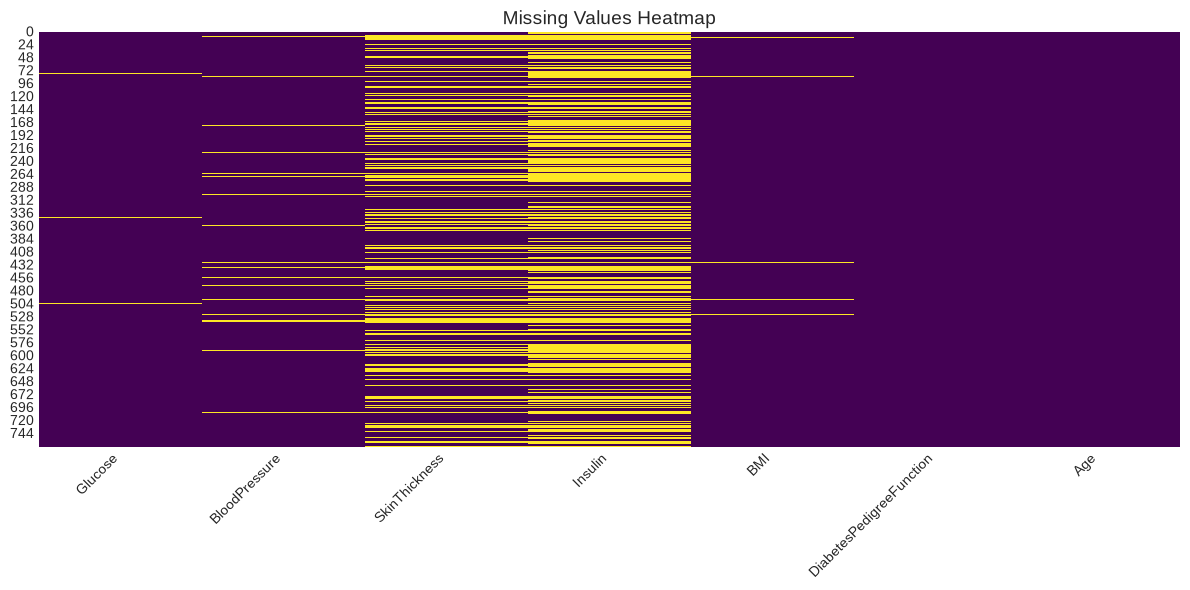

In [108]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

diabetes_df = diabetes_df[cols].replace(0, np.nan)

print('======= missing values count  ========')
print(diabetes_df.isna().sum())

print('\n\n======= missing values percentages ========')
print((diabetes_df.isna().mean()*100).round(2))

print('======= missing values heatmap ========')
plt.figure(figsize=(12, 6))
sns.heatmap(diabetes_df.isna(), cbar=False, cmap='viridis')

plt.xticks(rotation=45, ha='right')
plt.title("Missing Values Heatmap", fontsize=14)

plt.tight_layout()
plt.show()

<a id='4'></a>
## 4. Duplicate Check
- df.duplicated().sum()
- df['ID'].duplicated().sum()

In [109]:
# diabetes_df = diabetes_df.rename(columns={'Unnamed: 0' : 'ID'})
# print(f"duplicated ids count: {diabetes_df['ID'].duplicated().sum()}\n")
print(f"duplicates: {diabetes_df.duplicated().sum()}\n")
# diabetes_df = diabetes_df.drop(columns='ID')


duplicates: 0



<a id='5'></a>
## 5. Distribution Analysis
- `df.describe()`
- Histograms
- Boxplots
- Skewness analysis using `df.skew()`

In [110]:
display(diabetes_df.describe())

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000
mean,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885
std,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232
min,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000
25%,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000
50%,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000
75%,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000
max,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


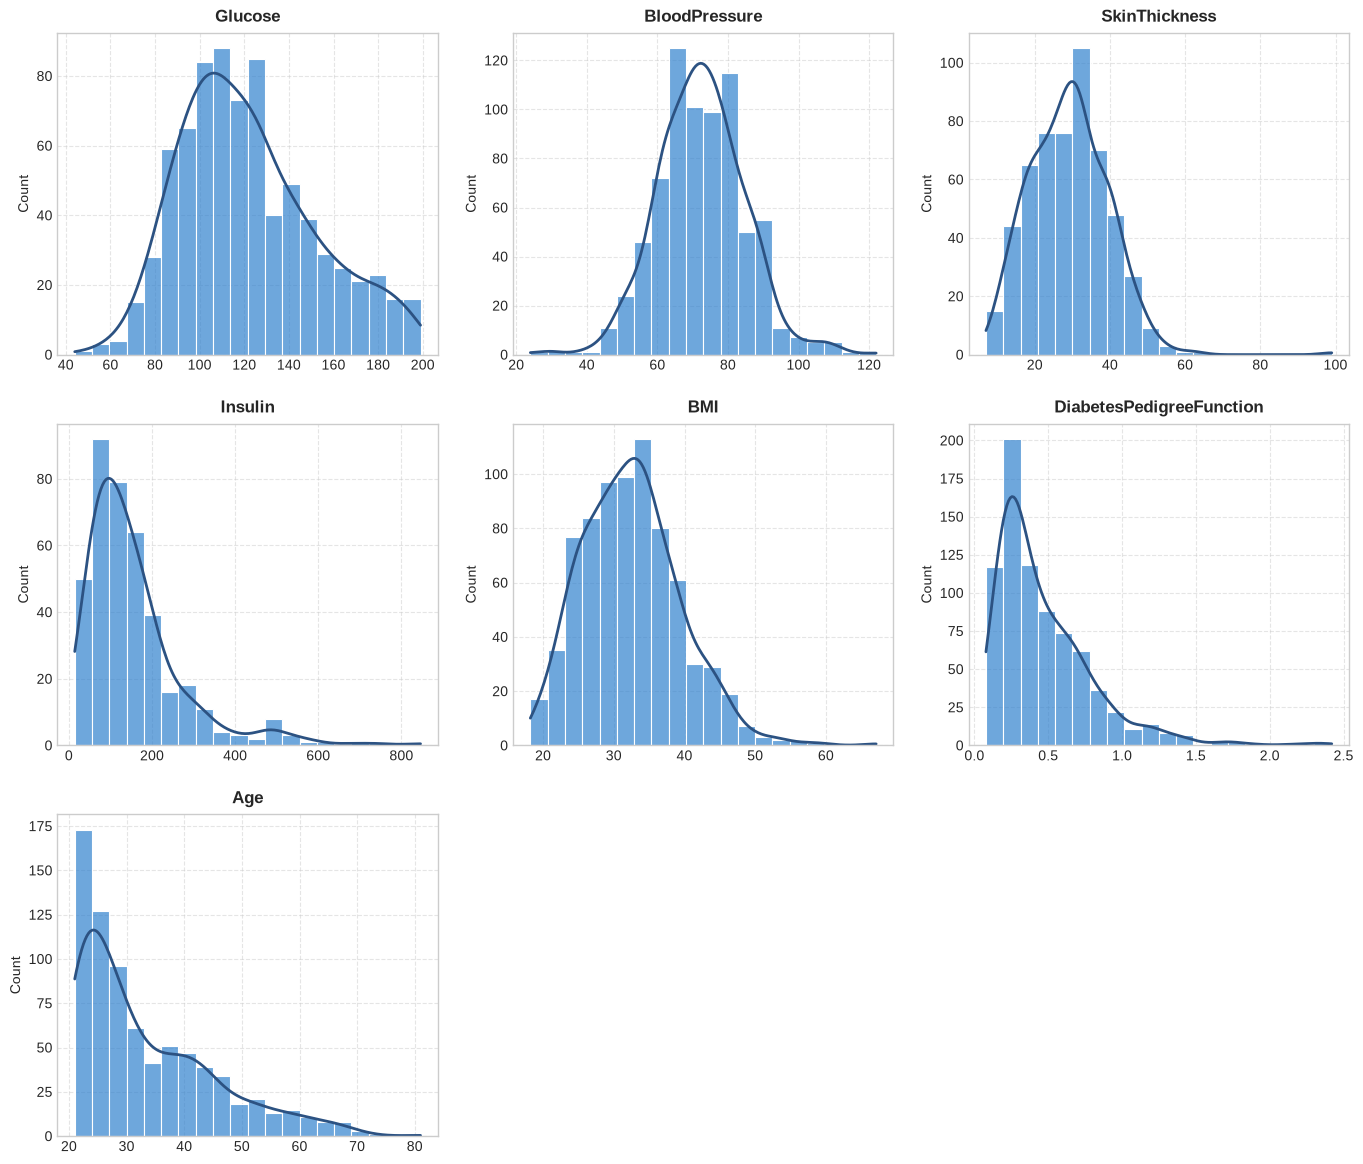

In [111]:
Painter.drawHsitKDE(diabetes_df, diabetes_df.columns, 3)



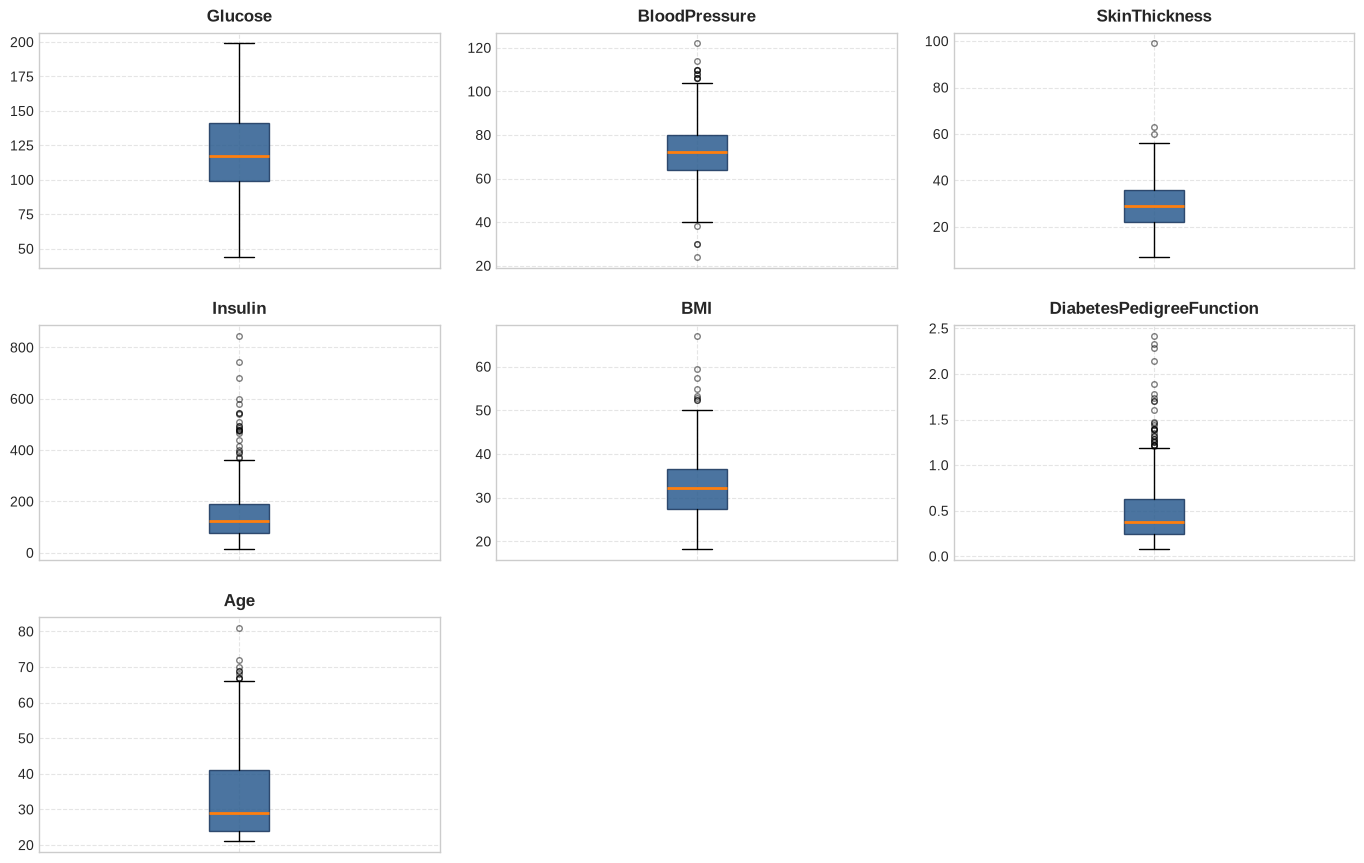

In [112]:
Painter.drawBoxplot(diabetes_df, diabetes_df.columns, 3, 1.5)

In [114]:
display(diabetes_df.skew())

diabetes_df.to_csv('../../data/raw/diabetesDataset.csv', index=False)



Glucose                     0.530989
BloodPressure               0.134153
SkinThickness               0.690619
Insulin                     2.166464
BMI                         0.593970
DiabetesPedigreeFunction    1.919911
Age                         1.129597
dtype: float64